<a href="https://colab.research.google.com/github/cpgh1/CorpSite/blob/master/PyTorch01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
what_were_covering = {1: "data (prepare and load)",
    2: "build model",
    3: "fitting the model to data (training)",
    4: "making predictions and evaluating a model (inference)",
    5: "saving and loading a model",
    6: "putting it all together"
}

In [2]:
import torch
from torch import nn # nn contains all of PyTorch's building blocks for neural networks
import matplotlib.pyplot as plt

# Check PyTorch version
torch.__version__

'2.11.0+cpu'

In [3]:
# Create *known* parameters
weight = 0.7 # For linear regression w = b (the slope) and bias = a (the intercept)
bias = 0.3

# Create data
start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1) # extra dimension added
y = weight * X + bias # This is in effect the linear regression formula y = a + bx

print(X[:10], y[:10])

print(len(X), len(y))

tensor([[0.0000],
        [0.0200],
        [0.0400],
        [0.0600],
        [0.0800],
        [0.1000],
        [0.1200],
        [0.1400],
        [0.1600],
        [0.1800]]) tensor([[0.3000],
        [0.3140],
        [0.3280],
        [0.3420],
        [0.3560],
        [0.3700],
        [0.3840],
        [0.3980],
        [0.4120],
        [0.4260]])
50 50


In [4]:
# Create train/test split
train_split = int(0.8 * len(X)) # 80% of data used for training set, 20% for testing
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

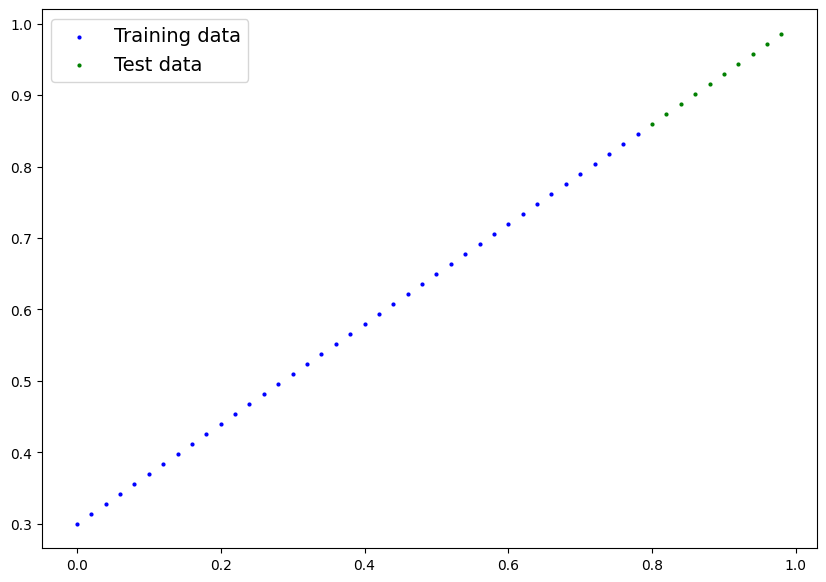

In [5]:
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None):

  plt.figure(figsize=(10,7))

  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")

  # Plot test data in green
  plt.scatter(test_data, test_labels, c="g", s=4, label="Test data")

  if predictions is not None:
    # Plot the predictions in red (predictions were made on the test data)
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  # Show the legend
  plt.legend(prop={"size": 14});

plot_predictions();

In [6]:
# Create a Linear Regression model class
class LinearRegressionModel(nn.Module): # <- almost everything in PyTorch is a nn.Module (think of this as neural network lego blocks)
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1, # <- start with random weights (this will get adjusted as the model learns)
                                                dtype=torch.float), # <- PyTorch loves float32 by default
                                   requires_grad=True) # <- can we update this value with gradient descent?)

        self.bias = nn.Parameter(torch.randn(1, # <- start with random bias (this will get adjusted as the model learns)
                                            dtype=torch.float), # <- PyTorch loves float32 by default
                                requires_grad=True) # <- can we update this value with gradient descent?))

    # Forward defines the computation in the model
    def forward(self, x: torch.Tensor) -> torch.Tensor: # <- "x" is the input data (e.g. training/testing features)
        return self.weights * x + self.bias # <- this is the linear regression formula (y = m*x + b)

In [7]:
# Set manual seed since nn.Parameter are randomly initialized
torch.manual_seed(42)

# Create an instance of the model (this is a subclass of nn.Module that contains nn.Parameter(s))
model_0 = LinearRegressionModel()

# Check the nn.Parameter(s) within the nn.Module subclass we created
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [8]:
# List named parameters
print(model_0.state_dict())

# These random weights and bias will be used to try anf get close to the
# actual weight and bias that we specified
print(weight, bias)

# In most cases you will NOT know what the 'ideal' values should be which is the
# whoe point of deep learning


OrderedDict({'weights': tensor([0.3367]), 'bias': tensor([0.1288])})
0.7 0.3


In [9]:
# Make predictions with model
# Inference mode turns off gradient tracking. This is a memory saving and
# speed related item with larger datasets
with torch.inference_mode():
    y_preds = model_0(X_test)

print(y_preds)
# Note: in older PyTorch code you might also see torch.no_grad()
# with torch.no_grad():
#   y_preds = model_0(X_test)

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])


Number of testing samples: 10
Number of predictions made: 10
Predicted values:
tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])


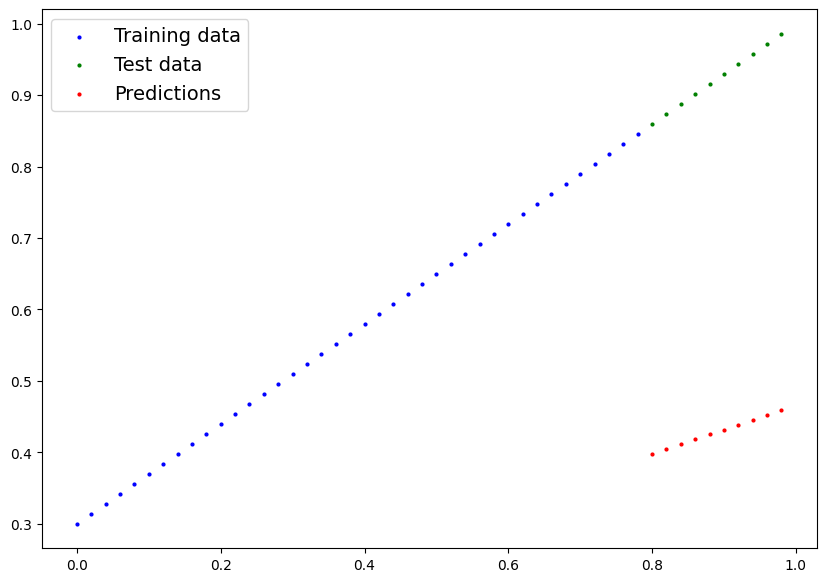

In [10]:
# Check the predictions
print(f"Number of testing samples: {len(X_test)}")
print(f"Number of predictions made: {len(y_preds)}")
print(f"Predicted values:\n{y_preds}")

plot_predictions(predictions=y_preds)

In [11]:
print(list(model_0.parameters()))

print(model_0.state_dict())

[Parameter containing:
tensor([0.3367], requires_grad=True), Parameter containing:
tensor([0.1288], requires_grad=True)]
OrderedDict({'weights': tensor([0.3367]), 'bias': tensor([0.1288])})


In [12]:
# Setup a loss function
loss_fn = nn.L1Loss()


# Setup an optimizer (stochastic gradient descent - SGD)
# lr is a step level adjustment that can be set by us (a hyperparameter) so 0.01 will adjust the
# weight and bias in steps of 0.01 to determine the loss function
optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.01)

In [15]:
# Building a training loop (and a testing loop) in PyTorch
# 0. Loop through the data and do...
# 1. Forward pass (also called forward propagation) - This involves data moving through our model's
#    "forward()" functions to make preditions on data
# 2. Calculate the loss (compare forward pass predictions to ground truth labels)
# 3. Optimize zero grad
# 4. Loss backward - move backwards through the network to calculate the gradients of
#    each of the parameters of our model with respect to the loss (*backpropagation*)
# 5. Optimizer step - use the optimizer to adjust our model's parameters to try
#    and improve the loss (i.e. minimize it) *gradient descent*

torch.manual_seed(42)
# An epoch is one loop through the data. This is a hyperparameter
epochs = 100

# Create empty loss lists to track values
train_loss_values = []
test_loss_values = []
epoch_count = []

# Training
# 0. Loop through the data
for epoch in range(epochs):
  # Set the model to training mode
  model_0.train()

  # 1. Forward pass
  y_pred = model_0(X_train)

  # 2. Calculate the loss
  loss = loss_fn(y_pred, y_train)
  #print(loss)
  #print(model_0.state_dict())

  # 3. Optimizer zero grad. Have to zero here otherwise we would accumulate on each
  #    pass through the loop
  optimizer.zero_grad()

  # 4. Perform backpropagation on the loss with respect to the parameters of the model
  loss.backward()

  # 5. Step the optimizer (perfrom gradient descent)
  optimizer.step()


  # *** Testing ***
  #Turns off different settings in the model not needed for evalluation/testing
  model_0.eval() # turns off gradient tracking

  with torch.inference_mode(): # Turns off gradient tracking
    # 1. Do the forward pass
    test_pred = model_0(X_test)

  # 2. Calculate the loss (the test loss)
  test_loss = loss_fn(test_pred, y_test)

  if epoch % 10 == 0:
    epoch_count.append(epoch)
    train_loss_values.append(loss.detach().numpy())
    test_loss_values.append(test_loss.detach().numpy())
    print(f"Epoch: {epoch} | MAE Train Loss: {loss} | MAE Test Loss: {test_loss} ")
    print(f"Epoch: {epoch} | Loss: {loss} | Test loss: {test_loss}")



Epoch: 0 | MAE Train Loss: 0.024458957836031914 | MAE Test Loss: 0.05646304413676262 
Epoch: 0 | Loss: 0.024458957836031914 | Test loss: 0.05646304413676262
Epoch: 10 | MAE Train Loss: 0.021020207554101944 | MAE Test Loss: 0.04819049686193466 
Epoch: 10 | Loss: 0.021020207554101944 | Test loss: 0.04819049686193466
Epoch: 20 | MAE Train Loss: 0.01758546568453312 | MAE Test Loss: 0.04060482233762741 
Epoch: 20 | Loss: 0.01758546568453312 | Test loss: 0.04060482233762741
Epoch: 30 | MAE Train Loss: 0.014155393466353416 | MAE Test Loss: 0.03233227878808975 
Epoch: 30 | Loss: 0.014155393466353416 | Test loss: 0.03233227878808975
Epoch: 40 | MAE Train Loss: 0.010716589167714119 | MAE Test Loss: 0.024059748277068138 
Epoch: 40 | Loss: 0.010716589167714119 | Test loss: 0.024059748277068138
Epoch: 50 | MAE Train Loss: 0.0072835334576666355 | MAE Test Loss: 0.016474086791276932 
Epoch: 50 | Loss: 0.0072835334576666355 | Test loss: 0.016474086791276932
Epoch: 60 | MAE Train Loss: 0.00385177647694

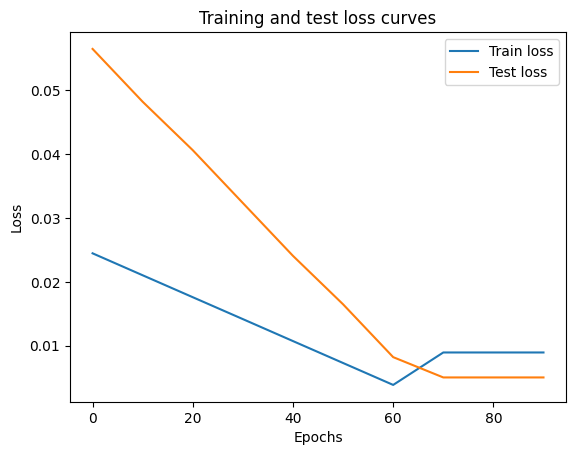

In [22]:
# Plot the loss curves
plt.plot(epoch_count, train_loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();

In [16]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [17]:
with torch.inference_mode():
  y_preds_new = model_0(X_test)


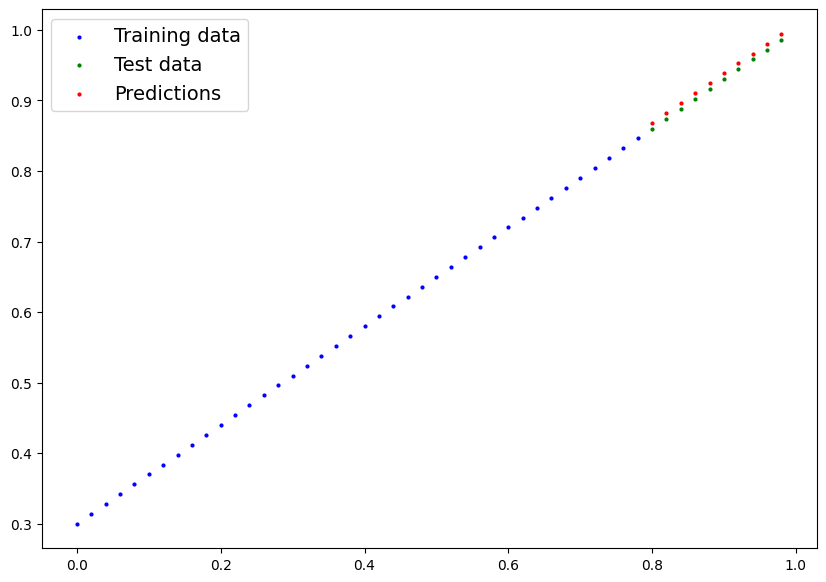

In [18]:
plot_predictions(predictions=y_preds_new)

In [17]:
# Ignore this cell. This is the example from PyTorch

loss = nn.L1Loss()
input = torch.randn(3, 5, requires_grad=True)
target = torch.randn(3, 5)

print(input)
print(target)

output = loss(input, target)

print(output)
print(output.backward())

tensor([[ 0.2345,  0.2303, -1.1229, -0.1863,  2.2082],
        [-0.6380,  0.4617,  0.2674,  0.5349,  0.8094],
        [ 1.1103, -1.6898, -0.9890,  0.9580,  1.3221]], requires_grad=True)
tensor([[ 0.8172, -0.7658, -0.7506,  1.3525,  0.6863],
        [-0.3278,  0.7950,  0.2815,  0.0562,  0.5227],
        [-0.2384, -0.0499,  0.5263, -0.0085,  0.7291]])
tensor(0.8332, grad_fn=<MeanBackward0>)
None
